In [2]:
# Do not change this cell

import torch
from torch import nn

import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader, SubsetRandomSampler
from torchinfo import summary

import matplotlib.pyplot as plt
from timeit import default_timer as timer

import numpy as np

random_seed = 1
torch.manual_seed(random_seed)
np.random.seed(random_seed)

transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
])

train_transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
])

trainset = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=ToTensor()
)
validationset = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=ToTensor()
)
testset = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=ToTensor()
)
classes = trainset.classes

valid_size = 0.2
train_length = len(trainset)
indices = list(range(len(trainset)))
split = int(np.floor(valid_size * train_length))

np.random.shuffle(indices)

train_idx=indices[split:]
valid_idx=indices[:split]
train_sampler=SubsetRandomSampler(train_idx)
validation_sampler=SubsetRandomSampler(valid_idx)

batch_size = 256
train_loader = DataLoader(trainset, batch_size=batch_size, sampler=train_sampler)
valid_loader = DataLoader(trainset, batch_size=batch_size, sampler=validation_sampler)
test_loader = DataLoader(testset, batch_size=batch_size, shuffle=False)

print(f"Length of train data loader: {len(train_loader)} batches of {batch_size}")
print(f"Length of validation data loader: {len(valid_loader)} batches of {batch_size}")
print(f"Length of test data loader: {len(test_loader)} batches of {batch_size}")

# Check out what is inside the training data loader
train_features_batch, train_label_batch = next(iter(train_loader))
print(train_features_batch.shape, train_label_batch.shape)

100%|██████████████████████████████████████| 26.4M/26.4M [00:22<00:00, 1.15MB/s]
100%|███████████████████████████████████████| 29.5k/29.5k [00:00<00:00, 188kB/s]
100%|██████████████████████████████████████| 4.42M/4.42M [00:02<00:00, 1.59MB/s]
100%|██████████████████████████████████████| 5.15k/5.15k [00:00<00:00, 4.25MB/s]

Length of train data loader: 188 batches of 256
Length of validation data loader: 47 batches of 256
Length of test data loader: 40 batches of 256
torch.Size([256, 1, 28, 28]) torch.Size([256])


In [4]:
# Do not change this cell
def imshow(img):
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

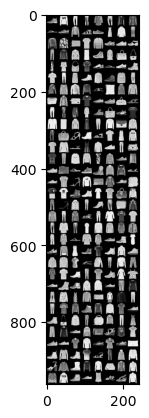

In [6]:
# Do not change this cell
dataiter = iter(test_loader)
images, labels = next(dataiter)
# Show images
imshow(torchvision.utils.make_grid(images))

In [28]:
# TODO: you will design your model here
class ConvModel(nn.Module):
    def __init__(self, input_size, output_size):
        # Initialize nn.Module state
        super(ConvModel, self).__init__()
        # Define convolutional layers (Conv2d)
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        # Define pooling layers (MaxPool)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Calculate 'flattened_size' = ((input_size - kernel_size + (2*padding) / stride) + 1) after conv and pooling
        # After conv1 and pool1: ((28 - 3 + (2*1) / 1) + 1) = 28 -> 28/2 = 14
        # After conv2 and pool2: 14 -> 14/2 = 7 (height and width)
        self.flattened_size = 64 * 7 * 7 # 64 channels and 7x7 image size

        # Define linear layers
        self.ln1 = nn.Linear(self.flattened_size, 128)
        self.ln2 = nn.Linear(128, output_size)

        # Define dropout for regularization
        self.dropout = nn.Dropout(0.2) # 20% dropout

        # ReLU Activation
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.pool1(x)
        x = self.relu(self.conv2(x))
        x = self.pool2(x)
        x = x.view(-1, self.flattened_size) # Flatten to 1D array
        x = self.relu(self.ln1(x))
        x = self.dropout(x)
        x = self.ln2(x)
        return x

In [30]:
def train_step(model, train_loader, loss_fn, optimizer, reg_param, device):
    # One epoch of training:
    # Set model to training mode and initialize train_loss, correct_predictions, and total_samples
    model.train()
    train_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    # Iterate through data of each batch
    for x, y in train_loader:
        # Move batch data to device
        x = x.to(device)
        y = y.to(device)

        # Zero gradients and complete forward pass
        optimizer.zero_grad()
        y_pred = model(x)
        pred_loss = loss_fn(y_pred, y)

        # L2 Regularization:
        l2_reg = torch.tensor(0.0).to(device) # Initialize L2 regulization term and add to device
        # Iterate through each parameter in the model
        for param in model.parameters():
            l2_reg += torch.norm(param) # Add L2 norm of each parameter
        # Calculate total loss (Total Loss = prediction loss + reg param × L2 norm)
        total_loss = pred_loss + reg_param * l2_reg

        # Backward pass and update weights
        total_loss.backward()
        optimizer.step()

        # Accumulate loss (scaled by batch size)
        train_loss += total_loss.item() * x.size(0)
        # Get predictions (class indices)
        _, predicted = torch.max(y_pred.data, 1)
        # Update total_samples and correct_predictions for accuracy calculation
        total_samples += y.size(0)
        correct_predictions += (predicted == y).sum().item()

    # Calculate average loss and accuracy
    train_loss /= total_samples
    train_accuracy = (correct_predictions / total_samples) * 100

    return train_loss, train_accuracy

In [32]:
def evaluation_step(model, data_loader, loss_fn, reg_param, device):
    # Set model to eval mode and initialize test_loss, correct_predictions, and total_samples
    model.eval()
    eval_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    # Disable gradient calculation for evaluation
    with torch.no_grad():
        # Iterate through data of each batch
        for x, y in data_loader:
            # Move batch data to device
            x = x.to(device)
            y = y.to(device)

            # Forward pass
            y_pred = model(x)
            loss = loss_fn(y_pred, y)

            # L2 Regularization:
            l2_reg = torch.tensor(0.0).to(device) # Initialize L2 regulization term and add to device
            # Iterate through each parameter in the model
            for param in model.parameters():
                l2_reg += torch.norm(param) # Add L2 norm of each parameter
            
            # Calculate total loss (Total Loss = prediction loss + reg param × L2 norm)
            loss = loss + reg_param * l2_reg

            # Accumulate loss (scaled by batch size)
            eval_loss += loss.item() * x.size(0)
            # Get predictions (class indices)
            _, predicted = torch.max(y_pred.data, 1)
            # Update total_samples and correct_predictions for accuracy calculation
            total_samples += y.size(0)
            correct_predictions += (predicted == y).sum().item()

    # Calculate average loss and accuracy
    eval_loss /= total_samples
    eval_accuracy = (correct_predictions / total_samples) * 100

    return eval_loss, eval_accuracy

In [42]:
def train_conv_model(train_loader, valid_loader, test_loader, random_seed):
    # Make device
    device = "cpu"
    if torch.cuda.is_available():
        device = "cuda"
    else:
        if torch.backends.mps.is_available():
            device = "mps"

    torch.manual_seed(random_seed)  # do not change this

    # Initialize model, loss function (Cross-Entropy), and optimizer (Adam)
    model = ConvModel(input_size=None, output_size=10).to(device)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

    # Hyperparameters (num_epochs, reg param, and learning rate)
    num_epochs = 50
    reg_param = 0.001
    learning_rate = 0.01

    # Track train/val/test losses and accuracies
    train_losses = []
    train_accuracies = []
    val_losses = []
    val_accuracies = []
    test_losses = []
    test_accuracies = []

    # Track best validation accuracy and weigths that produced it
    best_val_accuracy = 0.0
    best_model_weights = None

    # Iterate through epochs, apply 'train_step' and 'evaluation_step', and store losses/accuracies
    for epoch in range(num_epochs):
        train_loss, train_accuracy = train_step(model, train_loader, loss_fn, optimizer, reg_param, device)
        val_loss, val_accuracy = evaluation_step(model, valid_loader, loss_fn, reg_param, device)
        test_loss, test_accuracy = evaluation_step(model, test_loader, loss_fn, reg_param, device)

        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)
        test_losses.append(test_loss)
        test_accuracies.append(test_accuracy)

        # Print train/val/test losses and accuracies after each epoch
        print(f"Epoch {epoch+1}/{num_epochs}: "
             f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.2f}%, "
             f"Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.2f}%, "
             f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.2f}%")

        # Save model with best validation accuracy
        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            best_model_weights = model.state_dict() # Save model weights

    # Load best model
    model.load_state_dict(best_model_weights)

    return model, train_losses, train_accuracies, val_losses, val_accuracies, test_losses, test_accuracies

In [44]:
def plot_accuracy_performance(train_accuracies, valid_accuracies, test_accuracies):
    # Epochs start at 1
    epochs = range(1, len(train_accuracies) + 1)

    # Plot curves
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, train_accuracies, label='training accuracy', color='red')
    plt.plot(epochs, valid_accuracies, label='valid accuracy', color='blue')
    plt.plot(epochs, test_accuracies, label='test accuracy', color='green')

    plt.title('Accuracy Curves')
    plt.xlabel('# of Epochs')
    plt.ylabel('Prediction Accuracy (%)')
    plt.legend()
    plt.grid(False)

In [54]:
def plot_loss_performance(train_losses, valid_losses, test_losses):
    # Epochs start at 1
    epochs = range(1, len(train_losses) + 1)

    # Plot curves
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, train_losses, label='train loss', color='orange')
    plt.plot(epochs, valid_losses, label='valid loss', color='purple')
    plt.plot(epochs, test_losses, label='test loss', color='black')

    plt.title('Loss Curves (Cross-Entropy Loss)')
    plt.xlabel('# of Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(False)

In [48]:
# Do not change this cell
random_seed = 1
model, train_losses, train_accuracies, valid_losses, valid_accuracies, test_losses, test_accuracies\
= train_conv_model(train_loader, valid_loader, test_loader, random_seed)

Epoch 1/50: Train Loss: 1.3050, Train Accuracy: 59.15%, Val Loss: 0.7397, Val Accuracy: 74.02%, Test Loss: 0.7488, Test Accuracy: 73.76%
Epoch 2/50: Train Loss: 0.7024, Train Accuracy: 75.12%, Val Loss: 0.5956, Val Accuracy: 79.29%, Test Loss: 0.6073, Test Accuracy: 78.61%
Epoch 3/50: Train Loss: 0.5933, Train Accuracy: 79.40%, Val Loss: 0.5275, Val Accuracy: 81.70%, Test Loss: 0.5424, Test Accuracy: 81.52%
Epoch 4/50: Train Loss: 0.5367, Train Accuracy: 81.51%, Val Loss: 0.4868, Val Accuracy: 83.83%, Test Loss: 0.5066, Test Accuracy: 83.06%
Epoch 5/50: Train Loss: 0.4990, Train Accuracy: 82.93%, Val Loss: 0.4575, Val Accuracy: 84.39%, Test Loss: 0.4786, Test Accuracy: 83.91%
Epoch 6/50: Train Loss: 0.4763, Train Accuracy: 83.70%, Val Loss: 0.4356, Val Accuracy: 85.09%, Test Loss: 0.4549, Test Accuracy: 84.76%
Epoch 7/50: Train Loss: 0.4534, Train Accuracy: 84.72%, Val Loss: 0.4164, Val Accuracy: 85.69%, Test Loss: 0.4352, Test Accuracy: 85.21%
Epoch 8/50: Train Loss: 0.4351, Train Acc

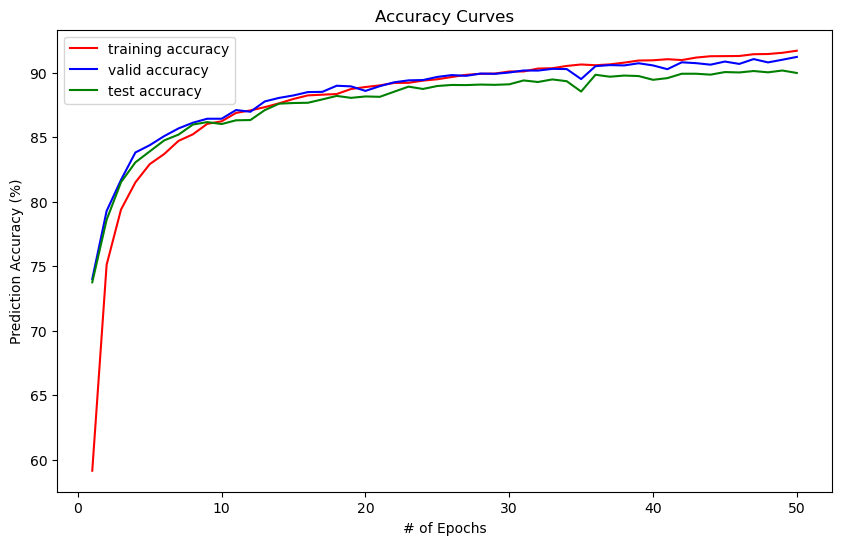

In [50]:
# Do not change this cell
plot_accuracy_performance(train_accuracies, valid_accuracies, test_accuracies)

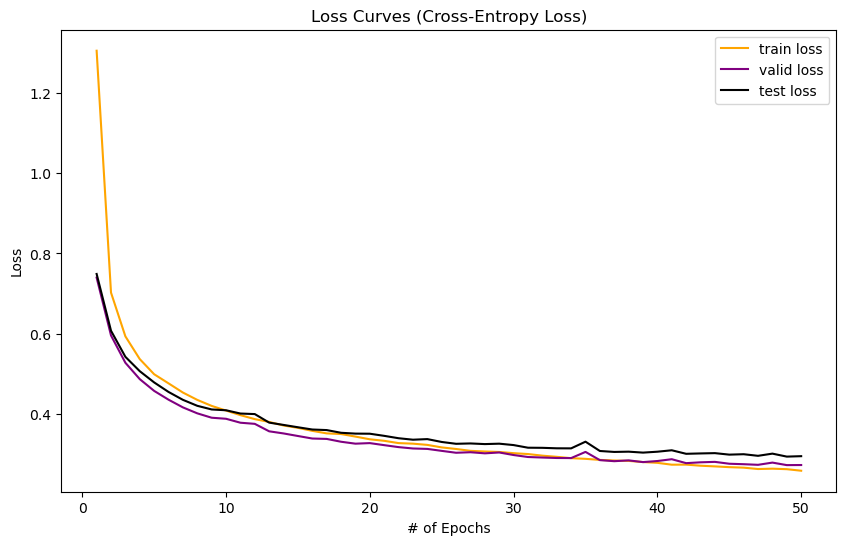

In [56]:
# Do not change this cell
plot_loss_performance(train_losses, valid_losses, test_losses)